In [348]:
import json
import os
import unicodedata

import numpy as np
import polars as pl
import torch
from gliner import GLiNER
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import BallTree
from sklearn.preprocessing import normalize
from tqdm import tqdm

DEVICE = (
    "mps"
    if torch.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
BASEPATH = "/Users/affahrizain/projects/phd-research/dataset/geotir"

In [251]:
def normalize_text(text):
    nfkd = unicodedata.normalize("NFKD", text)
    return "".join(c for c in nfkd if unicodedata.category(c) != "Mn").lower()

In [252]:
pov_cluster = pl.read_csv(os.path.join(BASEPATH, "pov_tower_cluster.csv")).with_columns(
    pl.concat_str(["title", "tags"], separator=" ").alias("text")
)
pov_centroid = pl.read_csv(
    os.path.join(BASEPATH, "pov_tower_centroid.csv")
).with_columns(
    [
        pl.col("member").str.split(",").list.eval(pl.element().cast(pl.Int64)),
        pl.col("neighbors").str.split(",").list.eval(pl.element().cast(pl.Int64)),
        pl.col("distances").str.split(",").list.eval(pl.element().cast(pl.Float64)),
    ]
)

wiki_df = (
    pl.read_csv(os.path.join(BASEPATH, "geotir_jp_gldv_wiki.csv"))
    .unique(subset=["wikimedia_url"])
    # .select(["wikimedia_url", "poi_name", "wikidata_id", "category", "poi_name_tags"])
    .with_columns(
        pl.col("poi_name_tags")
        .map_elements(
            lambda x: [n for names in json.loads(x).values() for n in names],
            return_dtype=pl.List(str),
        )
        .alias("poi_name_tags")
    )
    .with_columns(
        pl.col("poi_name_tags").list.eval(
            pl.element()
            .str.replace(r"^[^:]+:", "")
            .map_elements(normalize_text, return_dtype=pl.String)
        )
    )
)

poi_df = wiki_df.filter(pl.col("category") == "tower").with_row_index("row_idx")

In [324]:
poi_df

row_idx,wikimedia_url,poi_name,wikidata_id,instance_tag,category,poi_name_tags,geohack_url,latitude,longitude,country_code,country,region,subregion,city,osm_id,nearby_pov_cluster
u32,str,str,str,str,str,list[str],str,f64,f64,str,str,str,str,str,str,list[i64]
0,"""https://commons.wikimedia.org/…","""Omaesaki Lighthouse""","""Q7089383""","""[""lighthouse""]""","""tower""","[""omaesaki lighthouse"", ""御前埼燈塔"", … ""御前埼灯台""]","""https://geohack.toolforge.org/…",34.595833,138.225722,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Oyama""","""node/1804881162""",[]
1,"""https://commons.wikimedia.org/…","""Tokyo Skytree""","""Q9690280""","""[""observation tower"", ""transmi…","""tower""","[""東京スカイツリー"", ""tokyo skytree"", … ""tokyo skytree""]","""https://geohack.toolforge.org/…",35.710056,139.810722,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Urayasu""",null,[12]
2,"""https://commons.wikimedia.org/…","""Satamisaki lighthouse""","""Q7425874""","""[""lighthouse""]""","""tower""","[""satamisaki lighthouse"", ""佐多岬灯台""]","""https://geohack.toolforge.org/…",30.992222,130.659444,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ibusuki""","""node/1223941437""",[]
3,"""https://commons.wikimedia.org/…","""Toyosu Center Building""","""Q3536032""","""[""skyscraper""]""","""tower""","[""toyosu center building"", ""豊洲センターヒル"", … ""toyosu center building""]","""https://geohack.toolforge.org/…",35.6559,139.796,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Urayasu""",null,[]
4,"""https://commons.wikimedia.org/…","""Mori Tower""","""Q1771772""","""[""skyscraper""]""","""tower""","[""mori tower"", ""roppongi hills mori tower"", … ""torre mori de roppongi hills""]","""https://geohack.toolforge.org/…",35.660556,139.729167,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""","""way/153924771""",[10]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
151,"""https://commons.wikimedia.org/…","""Oasis Hiroba 21""","""Q5359208""","""[""skyscraper""]""","""tower""","[""oasisひろは21"", ""oasisひろは"", … ""oasis hiroba 21""]","""https://geohack.toolforge.org/…",33.238056,131.601667,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Oita""",null,[]
152,"""https://commons.wikimedia.org/…","""Yokohama Marine Tower""","""Q1207989""","""[""lighthouse"", ""observation to…","""tower""","[""marine tower yokohama"", ""横浜マリンタワー"", … ""menara laut yokohama""]","""https://geohack.toolforge.org/…",35.44393,139.6509,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Yokohama""",null,[]
153,"""https://commons.wikimedia.org/…","""Peace Tower, Miyazaki""","""Q11391724""","""[""monument"", ""tower""]""","""tower""","[""平和の塔"", ""八紘一宇の塔"", … ""вежа міру""]","""https://geohack.toolforge.org/…",31.948056,131.414444,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Miyazaki-shi""","""way/248621767""",[]


### Precompute NER

In [253]:
NER_MODEL = GLiNER.from_pretrained("urchade/gliner_multi-v2.1", load_tokenizer=True).to(
    DEVICE
)
NER_LABELS = ["tower"]

/Users/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 35665.85it/s]


In [254]:
extracted_ner = []

for txt in tqdm(pov_cluster["text"].to_list(), desc="NER"):
    entities = NER_MODEL.predict_entities(txt, NER_LABELS, threshold=0.5)
    extracted_ner.append([normalize_text(e["text"]) for e in entities])

pov_cluster = pov_cluster.with_columns(pl.Series("entities", extracted_ner))
pov_centroid = pov_centroid.join(
    pov_cluster.group_by("cluster_id").agg(
        pl.col("entities").list.explode(keep_nulls=False, empty_as_null=False)
    ),
    on="cluster_id",
    how="left",
)

NER: 100%|██████████| 10660/10660 [04:34<00:00, 38.87it/s]


In [255]:
all_rows = pov_centroid.to_dicts()

# vectorize ner features
vectorizer = TfidfVectorizer()
vectorizer.fit([i for ent in pov_cluster["entities"].to_list() for i in ent])
entity_feat = normalize(
    np.vstack(
        [
            np.array(vectorizer.transform(row["entities"]).mean(axis=0))
            for row in all_rows
        ]
    )
)

# make pairs
pairs = np.array(
    [
        (row["cluster_id"], n)
        for row in all_rows
        for n in row["neighbors"]
        if n != row["cluster_id"]
    ]
)

# cosine similarity
sims = np.einsum("ij,ij->i", entity_feat[pairs[:, 0]], entity_feat[pairs[:, 1]])
merge_pairs = pairs[sims > 0.75]

# assign new cluster_id
n = len(all_rows)
adj = csr_matrix(
    (np.ones(len(merge_pairs)), (merge_pairs[:, 0], merge_pairs[:, 1])), shape=(n, n)
)
_, new_labels = connected_components(adj, directed=False)
cluster_id_map = pov_centroid.select("cluster_id").with_columns(
    pl.Series(new_labels).alias("new_cluster_id")
)

In [256]:
pov_cluster = (
    pov_cluster.join(cluster_id_map, on="cluster_id", how="left")
    .with_columns(pl.col("new_cluster_id").alias("cluster_id"))
    .drop("new_cluster_id")
)

In [257]:
def spherical_centroid(lats, lons):
    lat_rad = np.radians(lats)
    lon_rad = np.radians(lons)

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    x_mean = x.mean()
    y_mean = y.mean()
    z_mean = z.mean()

    lon_centroid = np.arctan2(y_mean, x_mean)
    hyp = np.sqrt(x_mean**2 + y_mean**2)
    lat_centroid = np.arctan2(z_mean, hyp)

    return np.degrees(lat_centroid), np.degrees(lon_centroid)

In [258]:
pov_centroid = (
    pov_centroid.join(cluster_id_map, on="cluster_id", how="left")
    .group_by("new_cluster_id")
    .agg(
        [
            pl.col("member").explode(),
            pl.col("latitude"),
            pl.col("longitude"),
            pl.col("entities").explode(),
        ]
    )
    .with_columns(
        pl.struct(["latitude", "longitude"])
        .map_elements(
            lambda row: spherical_centroid(
                np.array(row["latitude"]), np.array(row["longitude"])
            ),
            return_dtype=pl.List(pl.Float64),
        )
        .alias("centroid")
    )
    .with_columns(
        [
            pl.col("centroid").list.get(0).alias("latitude"),
            pl.col("centroid").list.get(1).alias("longitude"),
            pl.col("new_cluster_id").alias("cluster_id"),
        ]
    )
    .drop(["centroid", "new_cluster_id"])
    .select(["cluster_id", "latitude", "longitude", "member", "entities"])
    .sort("cluster_id")
)

### POV to POI Relation

In [259]:
poi_coords = np.radians(poi_df[["latitude", "longitude"]].to_numpy())
pov_coords = np.radians(pov_centroid[["latitude", "longitude"]].to_numpy())

R = 6371.0
eps_km = 0.1
eps_rad = eps_km / R
tree = BallTree(pov_coords, metric="haversine")

In [260]:
query_rads = 1 / R
indices, distances = tree.query_radius(poi_coords, r=query_rads, return_distance=True)

Spatial proximity

In [261]:
poi_df = poi_df.with_columns(
    pl.Series(
        "nearby_pov_cluster", [i.tolist() for i in indices], dtype=pl.List(pl.Int64)
    )
)

In [262]:
poi_df_w_nearby_cluster = (
    poi_df.filter((pl.col("nearby_pov_cluster").list.len() > 0))
    .drop("row_idx")
    .with_row_index("row_idx")
)
poi_df_w_nearby_cluster

row_idx,wikimedia_url,poi_name,wikidata_id,instance_tag,category,poi_name_tags,geohack_url,latitude,longitude,country_code,country,region,subregion,city,osm_id,nearby_pov_cluster
u32,str,str,str,str,str,list[str],str,f64,f64,str,str,str,str,str,str,list[i64]
0,"""https://commons.wikimedia.org/…","""Tokyo Skytree""","""Q9690280""","""[""observation tower"", ""transmi…","""tower""","[""東京スカイツリー"", ""tokyo skytree"", … ""tokyo skytree""]","""https://geohack.toolforge.org/…",35.710056,139.810722,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Urayasu""",null,[12]
1,"""https://commons.wikimedia.org/…","""Mori Tower""","""Q1771772""","""[""skyscraper""]""","""tower""","[""mori tower"", ""roppongi hills mori tower"", … ""torre mori de roppongi hills""]","""https://geohack.toolforge.org/…",35.660556,139.729167,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""","""way/153924771""",[10]
2,"""https://commons.wikimedia.org/…","""GranTokyo""","""Q2913602""","""[""skyscraper"", ""twin towers"", …","""tower""","[""クラントウキョウ"", ""クラントウキョウノースタワー"", … ""غران طوكيو""]","""https://geohack.toolforge.org/…",35.681694,139.768972,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",null,"[26, 27]"
3,"""https://commons.wikimedia.org/…","""Umeda Sky Building""","""Q1151808""","""[""skyscraper""]""","""tower""","[""梅田蓝天大厦"", ""梅田藍天大廈"", … ""umeda sky building""]","""https://geohack.toolforge.org/…",34.705278,135.489722,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Osaka-shi""","""relation/3389505""",[0]
4,"""https://commons.wikimedia.org/…","""Ginza Mitsui Building""","""Q47398718""","""[""tower block""]""","""tower""","[""銀座三井ヒルティンク"", ""ginza mitsui building"", ""ginza mitsui binası""]","""https://geohack.toolforge.org/…",35.667028,139.763139,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",null,"[20, 21]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
48,"""https://commons.wikimedia.org/…","""Shinjuku Nomura Building""","""Q1048673""","""[""skyscraper""]""","""tower""","[""新宿野村大厦"", ""新宿野村大廈"", … ""shinjuku nomura binası""]","""https://geohack.toolforge.org/…",35.692778,139.695278,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",null,"[14, 15, … 19]"
49,"""https://commons.wikimedia.org/…","""Nihonbashi Mitsui Tower""","""Q3125027""","""[""skyscraper""]""","""tower""","[""日本桥三井塔楼大厦"", ""日本橋三井塔"", … ""برج نيهونباشي ميتسوي""]","""https://geohack.toolforge.org/…",35.686944,139.773056,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",null,"[26, 27]"
50,"""https://commons.wikimedia.org/…","""Enoshima Sea Candle""","""Q11550565""","""[""lighthouse"", ""observation to…","""tower""","[""江の島灯台"", ""江の島シーキャントル"", … ""plateforme d'observation d'enoshima""]","""https://geohack.toolforge.org/…",35.299722,139.478333,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fujisawa""","""way/1311985404""",[9]


In [263]:
import plotly.colors as pc
import plotly.graph_objects as go

_pov_pd = pov_cluster.to_pandas()
_poi_pd = poi_df_w_nearby_cluster.to_pandas()


# Map cluster_id to colors: -1 (noise) → lightgray, others → qualitative palette
palette = pc.qualitative.Plotly
unique_clusters = sorted(c for c in _pov_pd["cluster_id"].unique() if c != -1)
color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(unique_clusters)}
color_map[-1] = "lightgray"
pov_colors = _pov_pd["cluster_id"].map(color_map).tolist()

fig = go.Figure()

fig.add_trace(
    go.Scattermap(
        lat=_pov_pd["latitude"],
        lon=_pov_pd["longitude"],
        mode="markers",
        marker=dict(size=6, color=pov_colors, opacity=0.7),
        name="POV",
        hovertemplate=("POV<br>Cluster ID: %{customdata[0]}<extra></extra>"),
        customdata=_pov_pd[["cluster_id"]].values,
    )
)

fig.add_trace(
    go.Scattermap(
        lat=_poi_pd["latitude"],
        lon=_poi_pd["longitude"],
        mode="markers",
        marker=dict(size=10, color="#2893c1", opacity=0.7),
        name="POI",
        hovertemplate=(
            "POI %{customdata[0]} (%{customdata[1]})<br>Nearby Cluster: [%{customdata[2]}]<extra></extra>"
        ),
        customdata=_poi_pd[["row_idx", "poi_name", "nearby_pov_cluster"]].values,
    )
)

fig.update_layout(
    map=dict(center={"lat": 35.6895, "lon": 139.7517}, zoom=12),
    height=800,
    width=1200,
    margin=dict(l=10, r=10, t=10, b=10),
    legend=dict(x=0, y=1),
)

fig.show()

Lexical Confirmation

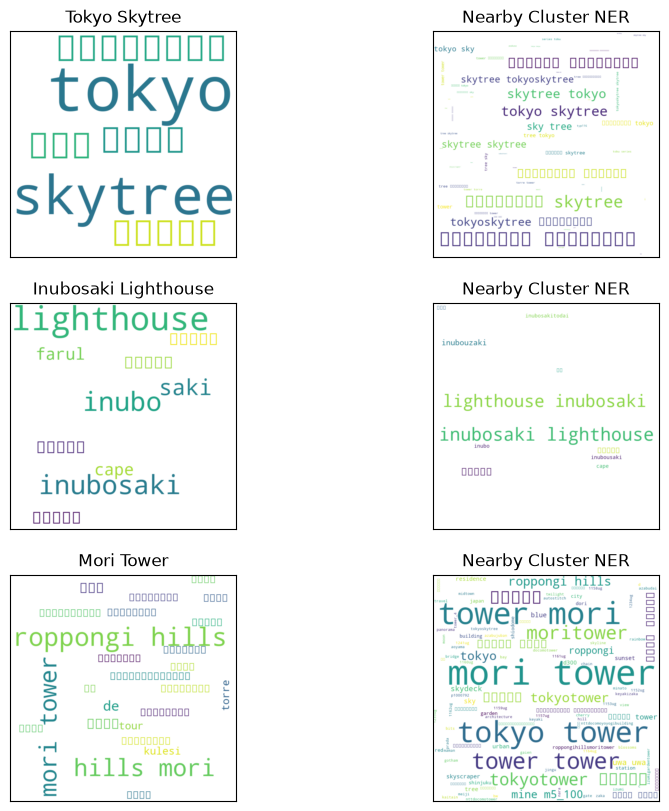

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# FONTPATH = "/opt/homebrew/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc"

_poi_0 = poi_df_w_nearby_cluster[0].to_dicts()[0]
_pov_0 = pov_centroid[12].to_dicts()[0]["entities"]
_poi_1 = poi_df_w_nearby_cluster[12].to_dicts()[0]
_pov_1 = pov_centroid[28].to_dicts()[0]["entities"]
_poi_2 = poi_df_w_nearby_cluster[1].to_dicts()[0]
_pov_2 = pov_centroid[10].to_dicts()[0]["entities"]

fig, ax = plt.subplots(3, 2, figsize=(10, 10))
# pov1
ax[0, 0].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_poi_0["poi_name_tags"])
    ),
    interpolation="bilinear",
)
ax[0, 0].set_title(_poi_0["poi_name"])

ax[0, 1].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_pov_0)
    ),
    interpolation="bilinear",
)
ax[0, 1].set_title("Nearby Cluster NER")


# pov2
ax[1, 0].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_poi_1["poi_name_tags"])
    ),
    interpolation="bilinear",
)
ax[1, 0].set_title(_poi_1["poi_name"])

ax[1, 1].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_pov_1)
    ),
    interpolation="bilinear",
)
ax[1, 1].set_title("Nearby Cluster NER")


# pov3
ax[2, 0].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_poi_2["poi_name_tags"])
    ),
    interpolation="bilinear",
)
ax[2, 0].set_title(_poi_2["poi_name"])

ax[2, 1].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(_pov_2)
    ),
    interpolation="bilinear",
)
ax[2, 1].set_title("Nearby Cluster NER")

for a in ax.flat:
    a.set_xticks([])
    a.set_yticks([])
plt.show()

In [ ]:
# vectorizer2 = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 6), use_idf=False)
vectorizer2 = CountVectorizer(analyzer="char_wb", ngram_range=(3, 4))
corpus = [i for ent in pov_centroid["entities"].to_list() for i in ent] + [
    i for ent in poi_df["poi_name_tags"].to_list() if ent for i in ent
]
vectorizer2.fit(corpus)

,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(3, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'char_wb'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'


In [321]:
pov_entity_feat = normalize(
    np.vstack(
        [
            np.array(vectorizer2.transform(entities).mean(axis=0))
            for entities in pov_centroid["entities"].to_list()
        ]
    )
)

poi_tags_feat = normalize(
    np.vstack(
        [
            np.array(vectorizer2.transform(tags).mean(axis=0))
            for tags in poi_df_w_nearby_cluster["poi_name_tags"].to_list()
        ]
    )
)

poi_pov_pairs = np.array(
    [
        (row["row_idx"], n)  # poi <-> pov
        for row in poi_df_w_nearby_cluster.to_dicts()
        for n in row["nearby_pov_cluster"]
    ]
)

sims = np.einsum(
    "ij,ij->i", poi_tags_feat[poi_pov_pairs[:, 0]], pov_entity_feat[poi_pov_pairs[:, 1]]
)

poi_pov_pairs[sims > 0.5]

array([[ 0, 12],
       [ 1, 10],
       [ 3,  0],
       [ 8,  5],
       [12, 28],
       [16, 20],
       [18,  1],
       [18,  2],
       [20, 19],
       [23,  3],
       [27, 10],
       [32, 21],
       [33, 30],
       [34,  0],
       [35, 14],
       [37, 14],
       [37, 19],
       [40, 14],
       [40, 19],
       [41, 11],
       [42, 16],
       [43, 21],
       [50,  9],
       [51, 14],
       [52, 18]])

In [322]:
poi_pov_pairs[sims > 0.5].shape

(25, 2)

In [ ]:
from collections import defaultdict

valid_pairs = poi_pov_pairs[sims > 0.5]

poi_to_valid_pov = defaultdict(list)
for poi_idx, pov_idx in valid_pairs:
    poi_to_valid_pov[int(poi_idx)].append(int(pov_idx))

poi_df_w_nearby_cluster = poi_df_w_nearby_cluster.with_columns(
    pl.Series(
        "valid_pov_neighbor",
        [
            poi_to_valid_pov.get(i, [])
            for i in poi_df_w_nearby_cluster["row_idx"].to_list()
        ],
        dtype=pl.List(pl.Int64),
    )
)
# poi_to_valid_pov

In [347]:
import plotly.colors as pc
import plotly.graph_objects as go

_pov_pd = pov_cluster.to_pandas()
_poi_pd = poi_df_w_nearby_cluster.to_pandas()


# Map cluster_id to colors: -1 (noise) → lightgray, others → qualitative palette
palette = pc.qualitative.Plotly
unique_clusters = sorted(c for c in _pov_pd["cluster_id"].unique() if c != -1)
color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(unique_clusters)}
color_map[-1] = "lightgray"
pov_colors = _pov_pd["cluster_id"].map(color_map).tolist()

fig = go.Figure()

fig.add_trace(
    go.Scattermap(
        lat=_pov_pd["latitude"],
        lon=_pov_pd["longitude"],
        mode="markers",
        marker=dict(size=6, color=pov_colors, opacity=0.7),
        name="POV",
        hovertemplate=("POV<br>Cluster ID: %{customdata[0]}<extra></extra>"),
        customdata=_pov_pd[["cluster_id"]].values,
    )
)

fig.add_trace(
    go.Scattermap(
        lat=_poi_pd["latitude"],
        lon=_poi_pd["longitude"],
        mode="markers",
        marker=dict(size=10, color="#2893c1", opacity=0.7),
        name="POI",
        hovertemplate=(
            "POI %{customdata[0]} (%{customdata[1]})<br>"
            "Nearby Cluster (Spatial): [%{customdata[2]}]<br>"
            "Valid Cluster (Spatial + Lexical): [%{customdata[3]}]<br><extra></extra>"
        ),
        customdata=_poi_pd[["row_idx", "poi_name", "nearby_pov_cluster", "valid_pov_neighbor"]].values,
    )
)

fig.update_layout(
    map=dict(center={"lat": 35.6895, "lon": 139.7517}, zoom=12),
    height=800,
    width=1200,
    margin=dict(l=10, r=10, t=10, b=10),
    legend=dict(x=0, y=1),
)

fig.show()

### IDK

In [364]:
entities = pl.read_csv("../dataset/csv/entities.csv").with_row_index("entity_id")
landmark = pl.read_csv("../../phd-research/dataset/geotir/geotir_jp_gldv.csv")
landmark = landmark.join(entities.select(["entity_id", "wikimedia_url", "poi_name", "category"]), on="wikimedia_url", how="left")
landmark.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,city,src,pred_label,pred_score,caption,entity_id,poi_name,category
str,i64,f64,f64,str,str,str,str,str,str,str,str,str,f64,str,u32,str,str
"""6ab55533bd1b4e64""",80562,34.737639,135.34175,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nishinomiya-hama""","""train""","""non_landmark""",0.9,"""Interior of a modern building …",4992,"""Nishinomiya""","""other"""
"""fd5a9b40c193f1d9""",51731,34.673786,133.803708,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Soja""","""train""","""non_landmark""",0.7,"""A grassy hill with trees, surr…",6183,"""Tsukuriyama Kofun (Okayama)""","""other"""
"""6dac95035a9c37aa""",143824,30.358611,130.528611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nishinoomote""","""train""","""non_landmark""",0.9,"""A bamboo forest in Japan, show…",5713,"""Yakushima""","""other"""
"""ba53dec335255684""",176282,35.48583,137.62711,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nakatsugawa""","""train""","""non_landmark""",0.9,"""A small bird perched on a bran…",4641,"""Mount Fujimidai""","""other"""
"""58b59908627d6970""",35933,34.666667,135.216667,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kobe""","""train""","""non_landmark""",0.7,"""Modern building with a large t…",2537,"""Port Island""","""other"""


In [369]:
landmark.write_csv("../dataset/csv/landmarks.csv")

In [ ]:
landmark.group_by("pred_label").agg(pl.len())

pred_label,len
str,u32
"""non_landmark""",66250
"""bridge""",5414
"""palace_castle""",3176
"""tower""",5252
"""monument_statue""",5075
"""arch_gate""",19677


In [368]:
landmark.group_by("category").agg(pl.len())

category,len
str,u32
"""arch_gate""",246
"""monument_statue""",860
"""tower""",2447
"""bridge""",2993
"""other""",93636
"""palace_castle""",4662
